# <font color="red"> **4.1 Análisis exploratorio y limpieza de datos**

El análisis exploratorio de datos (AED), o EDA por sus siglas en inglés, representa la fase inicial en la ciencia de datos y es un proceso creativo y de descubrimiento que sirve como paso previo esencial antes de realizar análisis estadístico avanzado o creación de modelos más complejos. Su objetivo es explorar la estructura de los datos, la calidad y la presencia de anomalías, no confirmar una hipótesis estadística preexistente. 

La exploración inicial revela aspectos cruciales como: posibles errores en la introducción de datos, patrones de valores ausentes, y correlaciones significativas entre variables y redundancias informativas que podrían afectar a la calidad del análisis. El debate sobre la delimitación precisa de los procesos que conforman el análisis exploratorio permanece vigente en la comunidad científica. Mientras algunos expertos consideran la limpieza de datos como una fase preliminar independiente, la intrincada interrelación entre la exploración y la depuración, junto con su dependencia del contexto específico de los datos, sugiere la conveniencia de un enfoque integrado. 

En resume, AED es una forma de entender, visualizar y extraer información relevante del set de datos para poder decidir cuál será la ruta o técnica más adecuada para su posterior procesamiento.

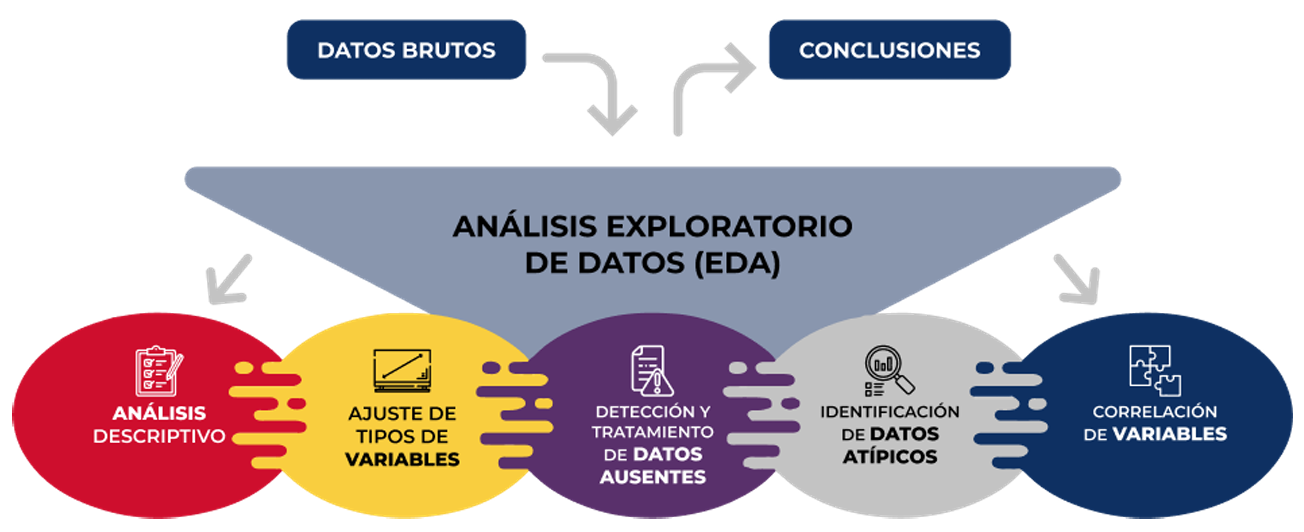

In [ ]:
#Vamos a importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Para calcular la distancia de Mahalanobis
import matplotlib.gridspec as gridspec

## <font color="brown"> **Planteamiento del problema**

#### **<font color="darkblue">Variables Hidrogeoquímicas de Pozos de Agua**

El agua subterránea es un recurso vital que soporta tanto los ecosistemas naturales como el desarrollo humano. La calidad del agua subterránea es influenciada por procesos hidrogeoquímicos que ocurren en el subsuelo, lo que afecta su composición química y, por ende, su uso para consumo humano, agrícola e industrial. La evaluación detallada de las características hidrogeoquímicas del agua subterránea es esencial para su gestión sostenible y protección. Este proyecto se enfoca en analizar las variables hidrogeoquímicas de pozos de agua, incluyendo temperatura ($T$), $pH$, potencial de óxido-reducción ($Eh$), y concentraciones de iones como '$Na^{+}$', '$K^{+}$', '$Ca_{2}$$^{+}$', '$HCO_{3}^{-}$', ' $SO_{4}^{2-}$', '$Cl^{-}$' y '$SiO_{2}$
'.

El objetivo es llevar a cabo un análisis exploratorio de datos (AED) para entender las relaciones entre estas variables y cómo podrían influir en la calidad del agua subterránea.

In [ ]:
#Vamos a cargar los datos 
pozo_hidro=pd.read_csv("/home/jovyan/Clase_py/Unidad4/Datos_Jaral_PreFinal.csv")

## <font color="olive"> **AED**

El análisis descriptivo nos permite realizar una caracterización inicial del conjunto de datos para comprender su estructura y contenido. Para ello, primero describiremos nuestos datos para posteriormente combinar dos aproximaciones complementarias: por un lado, la aplicación de técnicas de estadística descriptiva que nos proporcionarán una visión cuantitativa de las variables y sus características; por otro, la generación de visualizaciones que nos ayudarán a comprender intuitivamente los patrones de distribución presentes en los datos. Esta fase inicial de reconocimiento sienta las bases para cualquier análisis más profundo y dirigido. 

#### <font color="purple">**Características generales de los datos**

In [ ]:
#Primero vamos a visualizar nuestro datos

In [ ]:
#Columnas

In [ ]:
#Vamos a obtener información general de nuestros datos

**En resumen, ¿qué características podemos describir de nuestros datos?**

Los datos tienen una dimensión de **127 filas y 14 columnas**. Dentro de los cuales hay registro de **126 cuerpos de agua**. Cuenta con las siguientes columnas:

* `Localidad` nombre de la ubicación del cuerpo de agua
* `Tipo` cuerpo de agua entre pozos, manatiales, norias, presas.
* `Clase de Temp` variable categorica que define el grado de la temperatura del agua en baja, media y alta
* `T` Valor de la Temperatura ($°C$)
* `pH` Valor de la concentración de potencial de hidrogeno, medida de la acidez o alcalinidad de una solución acuosa
* `Eh` Potencial de óxido-reducción ($mV$)
* `Na+` Concentración del ión sodio ($mg/L$)
* `K+` Concentración del ión potasio ($mg/L$)
* `Ca2` Concentración del ión calcio ($mg/L$)
* `HC03` Concentración del ión bicarbonato ($mg/L$)
* `SO42-` Concentración del ión Sulfato ($mg/L$)
* `Cl-` Concentración del ión Cloro ($mg/L$)
* `SiO2` Concentración del ión Silice ($mg/L$)

Los datos se presentan en dos tipos: **float** y **object**. Además, nuestros datos contienen **valores faltantes en 5 columnas**. 

`Nota: Recuerden que los valores faltanes/nulos se pueden representar de otras maneras además del NaN`

---------------------------

Antes de profundizar el análisis descriptivo, es necesario preguntarnos qué tipos de modificaciones/transformaciones le podemos hacer a nuestros datos para garantizar que sean precisos, consistentes y utilizables para análisis posteriores. Este paso se le conoce como `limpieza de datos` el cual incluye **identificar y corregir errores, eliminar duplicados, manejar valores faltantes y estandarizar formatos**.

### <font color=purple> **Limpieza de datos**

En el caso de nuestros datos, ¿Qué podemos limpiar?

* Eliminar los espacios de los nombres de las columnas
* Valores faltantes de las columnas: No, Localidad, Tipo, Clase Temp, pH
* Estandarizar formatos a tipo string, int, float, categórico dependiendo el caso.
  

#### **<font color="orange"> Espacios**

In [ ]:
#Vamos a renombrar las columnas con espacios, ¿Cuáles serían?
pozo_hidro.columns

#Para ello vamos a aplicar el método strip(), el cual sirve para quitar espacios (u otros caracteres) al inicio y al final de la palabra.
pozo_hidro.columns = [col.strip() for col in pozo_hidro.columns]  #Ojo, el método no es útil cuando se quiere quitar espacio entre varias palabras

pozo_hidro.rename(columns={"Clase Temp":"Clase_Temp","HCO3 lab":"HCO3-"},inplace=True)

#### <font color=Orange> **Valores faltantes**

El manejo de `valores faltantes` es un aspecto crucial en la preparación de datos. Existen diversas estrategias para tratar con datos faltantes, cada una con sus ventajas y desventajas. A continuación, se describen algunas de las técnicas más comunes: 

- **Rellenar con estadísticos descriptivos**: 
    * Media: sustituir los valores ausentes con la media de la variable. Es útil cuando los datos están distribuidos normalmente y no hay muchos valores faltantes. 
    * Mediana: usar la mediana es una buena opción si los datos son asimétricos o contienen valores atípicos, ya que es menos sensible a estos extremos que la media. 
    * Moda: reemplazar con el valor más frecuente es adecuado para variables categóricas. 

- **Rellenar por valores adyacentes**: completar los valores faltantes con el valor de la fila o columna anterior o siguiente. Este método es útil en series temporales donde los datos suelen ser correlacionados en el tiempo.
      
- **Rellenar con cero**: para valores numéricos, rellenar con cero puede ser simple, pero es generalmente desaconsejado, ya que puede introducir sesgo significativo y alterar los resultados. 

- **Eliminar filas**: si los datos faltantes están presentes en un número pequeño de filas y el conjunto de datos es grande, se pueden eliminar estas filas. También puedes eliminarlos si no le aportan relevancia a tus análisis. Esta técnica puede ser útil para evitar rellenar datos, pero se debe tener cuidado de no perder información valiosa. 

- **Imputación con algoritmos de machine learning**: utilizar algoritmos para predecir los valores faltantes basados en otros datos. Esta técnica puede proporcionar un relleno de datos más preciso, pero es más compleja y computacionalmente intensiva. 

- **Eliminar variables**: En algunos casos, puede ser apropiado eliminar variables que tengan más del 50% de datos ausentes, especialmente si la variable es poco relevante para el análisis. 

La selección de la técnica de tratamiento adecuada depende del tipo de datos, la cantidad y patrón de los datos faltantes, y el contexto del análisis. Es esencial evaluar cómo cada método puede afectar a los resultados y la calidad del análisis final. Además, es importante documentar cuidadosamente cualquier decisión tomada en el tratamiento de datos ausentes. Un diseño riguroso del AED incluye la trazabilidad de estos procesos para poder evaluar su impacto y hacer ajustes si se detectan inconsistencias o debilidades en etapas posteriores del análisis.

In [ ]:
#En nuestro caso, solo tenemos valores faltantes en el índice 0. ¿Qué método creen que es el más adecuado para tratar estos NaN?
pozo_snan=pozo_hidro.drop(index=0,axis=0)

#### <font color="Orange"> **Estandarización de datos**

La estandarización de los datos es un proceso de limpieza y preparación que consiste en transformar los valores de un conjunto de datos para que tengan una escala común, lo que facilita su comparación y análisis. Además, la estandarización puede incluir la unificación de formatos (como fechas, unidades o texto) para asegurar consistencia en los datos. En conjunto, permite trabajar con información más homogénea, mejorar la interpretación de resultados y obtener análisis más robustos y comparables.

<font color=brown> **Una manera de estandarizar sus datos es replicando alguno de los métodos vistos en la clase de normalización, siempre y cuando sus objetivos lo requieran. En caso de que lo lleven a cabo, les recomiendo realizar la estandarización al final de la limpieza de sus datos.** 

En este caso, nos centraremos en unificar el formato de los datos.

Como pudimos obervar en celdas anteriores, tenemos dos tipos de datos *float* y de tipo *object*. Sim embargo, la mayoría de las columnas deberían de ser de tipo flotante. Cuando en pandas o NumPy les aparece `dtype = object` normalmente significa que los datos son objetos de Python pero que no tienen asignado un tipo específico, aunque visualmente lo parezcan. **¿Por qué pandas los clasifica así?**

**Causas más comunes**

* Números como texto `["1", "2", "3"]`. Parecen números, pero son strings.

* Valores mezclados `[1, 2, "3"]`. Cuando se mezclan pandas usa object para clasificarlos.

* Espacios o caracteres ocultos `["Jorge ", " Montse", " Adriana"]`. Esos espacios hacen que sean strings.

* Valores no numéricos `[1, 2, None, "NA"]`. Mezcla → object

* Símbolos `["1,000", "$200"]`. No son enteros directamente.

In [ ]:
#Vamos a averiguar por qué pasa esto
#Para ello, vamos a imprimir los valores únicos de cada columna y observar cómo es su formato

for i in pozo_snan.columns:
    print("Columna:",i, "Tipo", pozo_snan[i].dtype)
    print(np.unique(pozo_snan[i]))
    print("*-*-*-*-*-*-*-*-*"*5)

**Como pueden observar, en la columna Localidad existen espacios, en las columnas Clase_Temp y Tipo se representan categorías en las otras variables los números están escritos como texto.**

In [ ]:
#Primero borramos los espacios de la columna Localidad
pozo_snan["Localidad"] = [value.strip() for value in pozo_snan["Localidad"] ] 

#Ahora, convertimos los datos al tipo correcto
conversiones = {
    'No': 'int',
    'T': 'float64',
    'pH': 'float64',
    'Eh': 'float64',
    'Na+': 'float64',
    'K+': 'float64',
    'Ca2+': 'float64',
    'HCO3-': 'float64',
    'SO42-': 'float64',
    'Cl-': 'float64',
    'SiO2': 'float64',
    'Clase_Temp': 'category',
    'Tipo':'category'
}
# Aplicando la conversión de tipos de acuerdo al diccionario
pozo_snan = pozo_snan.astype(conversiones)

#Corroboramos
pozo_snan.info()

#### ¿Lograron observar algún otro error?

Si su respuesta es no, podemos continuar con mayor detalle para identificar posibles inconsistencias como **valores duplicados** o **valores erróneos**.

#### <font color="Orange"> **Valores duplicados**

Los valores duplicados son registros que aparecen más de una vez y que pueden representar la misma observación, ya sea de forma exacta o parcial. Estos duplicados pueden surgir por errores en la captura, problemas al combinar bases de datos o inconsistencias en los formatos, y su presencia puede distorsionar análisis estadísticos, generar sesgos o afectar modelos. Sin embargo, no siempre deben eliminarse automáticamente, ya que en algunos casos pueden corresponder a mediciones repetidas o información válida; por ello, es necesario identificarlos, analizar su origen y decidir si se eliminan, se corrigen o se permanecen dependiendo del contexto y del objetivo del análisis.

Un duplicado puede ser:

* Exacto: todas las columnas son iguales.
* Parcial: solo algunas columnas coinciden. 

In [ ]:
#Para analizar duplicados, vamos a regresar a ver nuevamente los valores únicos de cada columna
for i in pozo_snan.columns:
    print("Columna:",i, "Tipo", pozo_snan[i].dtype)
    print(np.unique(pozo_snan[i]))
    print("*-*-*-*-*-*-*-*-*"*5)

**La columna Tipo tiene dos nombres duplicados, exacto a dos categoría preexistente. Sin embargo, al estar escritas de diferente forma se consideran 
clasificaciones diferentes. Recuerden la importancia de las mayúsculas y minúsculas en la programación.**

In [ ]:
#Para ello ocupamos la función cat.rename_categories()
pozo_snan["Tipo"] = pozo_snan["Tipo"].cat.rename_categories({"pozo": "Pozo","manatial": "Manantial"})

In [ ]:
#Vamos a comprobar

#### <font color="orange"> **Valores erróneos**

Los valores erróneos son aquellos registros que no representan correctamente la realidad debido a errores de medición, captura, procesamiento o formato. Estos pueden manifestarse como valores fuera de rango (por ejemplo, temperaturas imposibles), datos mal codificados o incluso valores que no corresponden al tipo esperado. Su presencia puede afectar significativamente los resultados del análisis, por ello, es fundamental identificarlos mediante validaciones, reglas de consistencia o conocimiento del dominio, y posteriormente corregirlos, eliminarlos o transformarlos según el contexto y los objetivos del estudio.

Nuestros datos no cuentan con valores erróneos por lo que podemos continuar :)

### <font color="purple">**Estadística descriptiva**

**¿Qué hacen las estadísticas descriptivas?**
 * Organizar y resumir: Transforman datos crudos en información comprensible.
* Presentar información: Utilizan tablas, gráficos, diagramas y valores clave como promedios y porcentajes para resumir las características de un conjunto de datos.
* Describir características: Muestran dónde se ubica el "centro" de los datos y cómo se distribuyen o varían los valores.

**Tipos de estadísticas descriptivas**

`Medidas de tendencia central`

Indican la ubicación central de los datos:

1. **Media**: El promedio aritmético de un conjunto de datos.
2. **Mediana**: El valor medio cuando los datos están ordenados.
3. **Moda**: El valor que aparece con más frecuencia en los datos.
4. **Cuartiles**: Dividen al conjunto de datos en partes iguales.
    * $Q_{25}$: Valor por debajo del cual esta el 25% de los datos.
    * $Q_{50}$: Mediana
    * $Q_{75}$: Valor por debajo del cual esta el 75% de los datos.
      
5. **Simetría o sesgo**: si la media, moda y mediana de una distribución de datos coinciden, entonces es simétrica. De lo contrario podemos tener:
    * Sesgo positivo: Media > Mediana > Moda
    * Sesgo negativo: Media < Mediana < Moda


6. **Curtosis**: es una medida estadística que describe la forma de una distribución, específicamente qué tan concentrados están los datos alrededor de la media y qué tan pesadas son sus colas (es decir, la presencia de valores extremos). Los datos se compara normalmente con la distribución normal.

    * Curtosis alta (leptocúrtica)
  
      
        → Datos muy concentrados en el centro
        → Colas pesadas (más valores extremos)

    * Curtosis baja (platicúrtica)
  
      
        → Datos más dispersos
        → Colas ligeras (menos valores extremos)

    * Curtosis normal (mesocúrtica)
  
      
        → Similar a una distribución normal
      
`Medidas de dispersión`

Muestran la variabilidad o la dispersión de los datos.

1. **Rango**: La diferencia entre el valor máximo y mínimo.
2. **Desviación estándar**: Mide cuánto se alejan los datos del promedio.
3. **Varianza**: Representa el promedio de las distancias al cuadrado entre los datos y su media.
4. **Rango intercuartil (IQR)**:$Q_{75}-Q_{25}$

Lo primordial es empezar de menos a más. Por lo que primero vamos a observar la estadística descriptiva básica. Pero esto será trabajo de ustedes.

#### <font color="Orange"> **Estadística descriptiva básica**


### <font color="teal"> **Ejercicio 1** 

1. ¿Se le puede aplicar estadística a todas las columnas?. En caso de que no, selecciona las columnas que consideres que sí es posible.
2. Muestren los estadísticos descriptivos básicos de todos los datos.
3. Mustren los estadísticos descriptivos básicos pero ahora por cada columna.

----------------------

#### <font color="Orange"> **Estadística descriptiva avanzada**

Para ello, vamos a usar una función.

In [ ]:
def estadigrafos(df, VariableName):
    """
    Calcula estadísticas descriptivas básicas para una columna específica de un DataFrame.

    Parámetros:
    - df (pandas.DataFrame): DataFrame que contiene los datos.
    - VariableName (str): Nombre de la columna para la cual calcular las estadísticas.

    Retorna:
    - pandas.DataFrame: DataFrame con las estadísticas de la columna especificada.
    """
    # Calcula las estadísticas deseadas
    minim = df[VariableName].min()
    Q1 = df[VariableName].quantile(0.25)
    prome = df[VariableName].mean()
    moda=df[VariableName].mode().values
    Q2 = df[VariableName].median()
    Q3 = df[VariableName].quantile(0.75)
    maxim = df[VariableName].max()
    varia = df[VariableName].var()
    desvi = df[VariableName].std()
    rango = maxim - minim
    IQR = Q3 - Q1
    coefv = desvi / prome if prome != 0 else np.nan  # Previene división por cero
    simetria = df[VariableName].skew()
    curtosis = df[VariableName].kurtosis()

    # Crea un DataFrame con los resultados
    estadisticas = pd.DataFrame({
        VariableName: [minim, Q1, prome, moda,Q2, Q3, maxim, varia, desvi, rango, IQR, coefv, simetria, curtosis]
    }, index=['Mínimo', 'Primer Cuartil', 'Promedio', "Moda",'Mediana', 'Tercer Cuartil', 'Máximo', 'Varianza', 'Desviación Estandar', 'Rango', 'IQR', 'Coeficiente de variación', 'Simetria', 'Curtosis'])

    return estadisticas.round(2)

In [ ]:
# Vamos a observar la estadística descriptiva avanzada de la columna de pH
estadigrafos(pozo_snan, "pH")


### <font color="purple"> **Visualizaciones estadísticas**

En el Análisis Exploratorio de Datos, los histogramas y los diagramas de caja y bigotes (boxplots) son herramientas básicas para entender la distribución y detectar problemas en los datos.

Un `histograma` muestra cómo se distribuyen los valores de una variable continua dividiendo los datos en intervalos (bins). Nos permite observar la forma de la distribución (simétrica, sesgada), frecuencia de valores, presencia de múltiples picos (multimodalidad) o posibles valores atípicos (aunque no tan claros como en boxplot).

Un `boxplot` resume la distribución usando estadísticos clave. Nos permite observar la dispersión de los datos y valores atípicos (outliers). Recuerden, un valor se considera extremo si:

$$
x<Q1-1.5*IQR
$$
$$
x>Q3+1.5*IQR
$$

In [ ]:
# Vamos a elegir una variable y observar su histograma

frecuencias,intervalos= np.histogram(pozo_snan["T"], bins = 15)

plt.hist(pozo_snan["T"], bins=15,edgecolor="black",color="red",zorder=2)
plt.xlabel("Temperatura [$^\circ$C]")
plt.ylabel("Frecuencia")
plt.title("Histograma")
plt.xticks(intervalos,rotation=45)
plt.grid(color="gray",linestyle="--",alpha=0.3,zorder=1)
plt.show()

In [ ]:
#Gráfico de cajas
plt.boxplot(pozo_snan["T"],tick_labels=["Temperatura"],vert=True,showmeans=True,
           showfliers=True,  
           patch_artist=True, 
            meanline=True,
            boxprops = dict(facecolor= 'darkturquoise'),
            medianprops = dict(color = "darkgoldenrod", linewidth = 1.5), 
            meanprops = dict(color = "red", linewidth = 1.2),
            whiskerprops = dict(color = "purple", linewidth = 2),
            capprops = dict(color = "maroon", linewidth = 2.5), #Personalizar extremos
            flierprops = dict(marker = '*', markersize = 10, markerfacecolor = 'darkolivegreen')#Personalizar outliers
           ) 
plt.title("Boxplot")
plt.ylabel("Temperatura ($^\circ$C)")
plt.show()


In [ ]:
#Vamos a comprobarlo
T_esta=estadigrafos(pozo_snan, "T")
Q1=T_esta.loc[T_esta.index=='Primer Cuartil'].values
Q3=T_esta.loc[T_esta.index=='Tercer Cuartil'].values
iqr=T_esta.loc[T_esta.index=='IQR'].values

outlier_inf=Q1-(1.5*iqr)
outlier_sup=Q3+(1.5*iqr)

for i in pozo_snan["T"]:
    if i<outlier_inf[0]:
        print(i)

for i in pozo_snan["T"]:
    if i>outlier_sup[0]:
        print(i)

In [ ]:
#Vamos a hacer una visualización un poco más avanzada
def HistBox(variables, df):
    plt.figure(figsize=(20, 20))
    outer_grid = gridspec.GridSpec(6, 2, wspace=0.2, hspace=0.4)
    custom_params = {"axes.spines.right": True, "axes.spines.top": True, "axes.spines.left": True}
    sns.set_theme(style='whitegrid', context="talk", rc=custom_params, color_codes = True)
    sns.set_style("ticks", {"axes.grid": True, "grid.linestyle": "--"})

    for i, variable in enumerate(variables):
        inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1,
                                                      subplot_spec=outer_grid[i],
                                                      height_ratios=[4, 1],
                                                      hspace=0.02)  # Ajustado para minimizar el espacio entre histogramas y boxplots

        # Histograma
        ax_hist = plt.Subplot(plt.gcf(), inner_grid[0])
        sns.histplot(df[variable], kde=True, stat='density', color='yellowgreen', ax=ax_hist)
        ax_hist.set_title(variable)
        ax_hist.set_xlabel('')  # Mantener esto para limpieza
        plt.gcf().add_subplot(ax_hist)
        ax_hist.tick_params(axis='x',          # Cambios para ocultar solo los ticks (no las etiquetas, que ya están ocultas)
                            which='both',      # Afecta a ticks mayores y menores
                            bottom=False,      # Oculta ticks inferiores
                            top=False,         # Oculta ticks superiores (si estuvieran visibles)
                            labelbottom=False) # Oculta las etiquetas de los ticks inferiores
        # Calcula y anota estadísticas
        mean = df[variable].mean()
        median = df[variable].median()
        mode = df[variable].mode()[0]  # Moda
        max_value = df[variable].max()
        min_value = df[variable].min()

        # Agrega líneas verticales para cada estadística
        lines = [
            ax_hist.axvline(mean, color='red', linestyle='dashed', linewidth=2),
            ax_hist.axvline(median, color='green', linestyle='dashed', linewidth=2)#,
        ]

        ax_hist.grid(True)

        # Boxplot
        ax_box = plt.Subplot(plt.gcf(), inner_grid[1], sharex=ax_hist)
        sns.boxplot(x=df[variable], ax=ax_box, color='lightgreen', showmeans=True,
                    meanprops={"marker":"o", "markerfacecolor":'red',
                               "markeredgecolor":"gray", "markersize":"10"})
        ax_box.set_xlabel('')
        ax_box.tick_params(axis='x',          # Cambios para ocultar solo los ticks (no las etiquetas, que ya están ocultas)
                            which='both',      # Afecta a ticks mayores y menores
                            bottom=True,      # Oculta ticks inferiores
                            top=True,         # Oculta ticks superiores (si estuvieran visibles)
                            labelbottom=True)
        plt.gcf().add_subplot(ax_box)

In [ ]:
#Seleccionamos las variables a utilizar
VariablesNumAnalis = ['T', 'pH', 'Eh', 'Na+', 'K+', 'Ca2+', 'HCO3-', 'SO42-', 'Cl-', 'SiO2']

In [ ]:
HistBox(VariablesNumAnalis, pozo_snan)

### <font color=purple>**Valores atípicos**

Un valor atípico u outlier representa una observación que exhibe una desviación significativa respecto al patrón general de comportamiento del resto de los datos. Estas observaciones extremas pueden surgir por diversos motivos: desde errores en la medición o registro de datos hasta fenómenos reales pero extraordinarios que merecen especial atención. Su importancia en el análisis exploratorio es crucial, ya que pueden ejercer una influencia desproporcionada en los estadísticos descriptivos, distorsionar las relaciones entre variables y comprometer la validez de modelos estadísticos posteriores. 

La gestión adecuada de estos valores requiere un equilibrio entre la preservación de información potencialmente valiosa y la necesidad de  mantener la robustez del análisis estadístico. El enfoque más común para el manejo de outliers es reducir su posible influencia en los análisis. A  
continuación, se mencionan algunas estrategias que se pueden considerar: 

* **Métodos estadísticos robustos**: existen técnicas estadísticas robustas diseñadas para minimizar el impacto de los valores atípicos en los resultados. Estos métodos ajustan el análisis para que sea menos sensible a los outliers, preservando así la integridad de los resultados. 

* **Eliminación de outliers**: eliminar valores atípicos puede ser apropiado en algunos casos, pero debe hacerse con cuidado. Antes de descartar un outlier, es fundamental verificar si el valor es el resultado de un error de medición o de un problema en la construcción del dataset.

* **Sustitución de outliers**: reemplazar outliers por la media o la mediana, por ejemplo. Aunque esta práctica puede parecer una solución sencilla, puede alterar la distribución y la varianza de los datos, introduciendo sesgo en el análisis. 

Si se decide eliminar o sustituir los valores atípicos, es prudente repetir los análisis tanto con los valores originales como con los datos modificados. Esto permite observar el impacto real de los outliers en los resultados. Si la diferencia es mínima, puede ser razonable proceder con la eliminación o sustitución. Sin embargo, si el impacto es considerable, se debe justificar adecuadamente cualquier decisión. Independientemente del enfoque adoptado, como sucede con el tratamiento de los datos ausentes, también es crucial documentar todas las decisiones tomadas durante el proceso de manejo de outliers. 

----------------------

### <font color=purple> **Análisis de correlación entre variables**

La correlación (r) mide la relación lineal entre dos o más variables, reflejando tanto la fuerza como la dirección de su relación. En términos simples, la correlación nos indica si dos variables cambian juntas y de qué manera lo hacen: 

- **Correlación positiva**: si una variable aumenta y la otra también lo hace, se dice que están correlacionadas positivamente. Un valor de (r) cercano a +1 indica una relación positiva fuerte.
  
- **Correlación negativa**: si una variable aumenta mientras que la otra disminuye, están correlacionadas negativamente. Un valor de (r) cercano a -1 indica una relación negativa fuerte.

- **Sin correlación**: un valor de (r) cercano a 0 sugiere que no hay una relación lineal clara entre las variables. 

Es importante señalar que la correlación de Pearson, siendo la más común, no es la única medida de correlación disponible. Existen alternativas como: 
* `La correlación de Spearman`, más robusta frente a valores atípicos y útil para relaciones monótonas no lineales.
    
* `La correlación de Kendall`, especialmente útil para muestras pequeñas y cuando los datos no siguen una distribución normal. 
* `Medidas de correlación basadas en rangos`, que pueden capturar relaciones no lineales entre variables. 

El análisis de correlación puede ser útil en varios aspectos: 

• Identificación de redundancia: puede ayudar a identificar variables redundantes en un conjunto de datos. Si dos variables están altamente correlacionadas, una de ellas podría ser eliminada sin perder información significativa, lo que simplifica el análisis y el procesamiento de datos.

• Simplicidad en el análisis: en el contexto del AED, entender las correlaciones entre variables puede guiar la selección de variables para modelos predictivos y otros análisis estadísticos. 

• Relación con PCA: el análisis de correlación está relacionado con técnicas como el Análisis de Componentes Principales (PCA). PCA utiliza la matriz de correlación para transformar las variables originales en un nuevo conjunto de variables, llamadas componentes principales, que capturan la 
mayor variabilidad en los datos. 
 
**Es crucial recordar que correlación no implica causalidad**. Aunque dos variables puedan estar correlacionadas, no necesariamente significa que una cause cambios en la otra. La correlación simplemente indica una asociación y no establece una relación causal directa. 
 

In [ ]:
#Correlación entre las variables numéricas 
correlacion = pozo_snan[['T', 'pH', 'Eh', 'Na+', 'K+', 'Ca2+', 'HCO3-', 'SO42-', 'Cl-', 'SiO2']].corr()  #por default usa la de Pearson

In [ ]:
plt.figure(figsize=(25, 15)) 
# Gráfico de correlaciones utilizando un mapa de calor 
sns.heatmap(correlacion, annot=True, cmap='coolwarm', center=0, square=True, linewidths=.5, cbar_kws={"shrink": 1}) 
plt.title('Matriz de correlaciones entre variables') 
plt.show() 

### <font color="brown"> AED para variable categóricas

Para las variables contínuas se pueden obtener varias medidas que describan los datos, para el caso de variables categóricas la cosa cambia un poco.

`Nota: Para hacer el AED, deben separar las variables numéricas contínuas de las variables categóricas.`

In [ ]:
#Seleccionando las variables categóricas
VariablesCat = ['Tipo', 'Clase_Temp']

In [ ]:
#Estadística básica
pozo_snan[VariablesCat].describe()

In [ ]:
#Vamos a observar la frecuencia de nuestras variables
for i in VariablesCat:
    plt.figure(figsize=(10, 3))
    conteo = pozo_snan[i].value_counts()
    plt.bar(conteo.index, conteo.values, color='skyblue')
    plt.ylabel('Frecuencia absoluta')
    plt.title('Gráfico de barras de ' + i)
    plt.xticks(rotation=45)  
    plt.show()

In [ ]:
#Frecuencia relativa
for i in VariablesCat:
    plt.figure(figsize=(8, 5))
    frecuencia_relativa = pozo_snan[i].value_counts(normalize=True)
    plt.bar(frecuencia_relativa.index, frecuencia_relativa.values, color='skyblue')
    plt.ylabel('Frecuencia relativa')
    plt.title('Gráfico de barras de ' + i)
    plt.xticks(rotation=45)  
    plt.show()

### <font color="teal"> **Ejercicio 2**

Con los datos de earthquakes.csv:

1. Realizar la limpieza y organizacion de los datos.

2. Elijan 3 o 4 variables contínuas y 1 o 2 variables categóricas para hacer el AED.

Para mas informacion sobre la base de datos : <https://corgis-edu.github.io/corgis/csv/earthquakes/>



**Materiales recomendados**
* <https://datos.gob.es/sites/default/files/doc/file/guia_eda_python.pdf>
* <https://materials.campus.uoc.edu/daisy/Materials/PID_00265704/pdf/PID_00265704.pdf>